# Trabalho de IA
---

## Dataset 1

### Estimativa do Nível de Obesidade Baseado em Hábitos Alimentares e Condições Físicas
https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

### Modelos Aplicados
- Naive Bayes
- Multilayer Perceptron (MLP)

---

#### Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown, clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

## EDA

#### Carregamento dos Dados

In [20]:
sns.set_theme(style="whitegrid")

df = pd.read_csv('obesity.csv')

display(Markdown("**Amostra Inicial dos Dados:**"))
display(df.head())

**Amostra Inicial dos Dados:**

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [21]:
resumo_estrutural = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Nulos': df.isna().sum(),
    'Valores Únicos': df.nunique()
})

display(Markdown("**Resumo Estrutural das Variáveis:**"))
display(resumo_estrutural)

**Resumo Estrutural das Variáveis:**

,Tipo de Dado,Valores Nulos,Valores Únicos
Gender,str,0,2
Age,float64,0,1402
Height,float64,0,1574
Weight,float64,0,1525
family_history_with_overweight,str,0,2
FAVC,str,0,2
FCVC,float64,0,810
NCP,float64,0,635
CAEC,str,0,4
SMOKE,str,0,2


**Atributos com muitos valores únicos:**
- `Age`,
- `Height`,
- `Weight`,
- `FCVC` (Do you usually eat vegetables in your meals?),
- `NCP` (How many main meals do you have daily?),
- `CH2O` (How much water do you drink daily?),
- `FAF` (How often do you have physical activity?),
- `TUE` (How much time do you use technological devices...?).

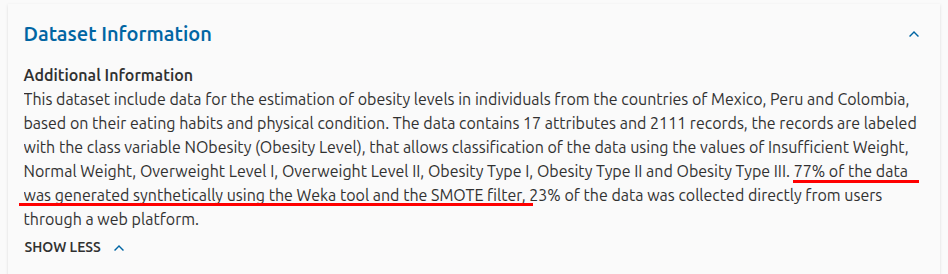

In [22]:
Image(filename='assets/dataset_info.png', width=1500)

**Distribuição da Variável Alvo (NObeyesdad):**

,Contagem,Proporção (%)
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


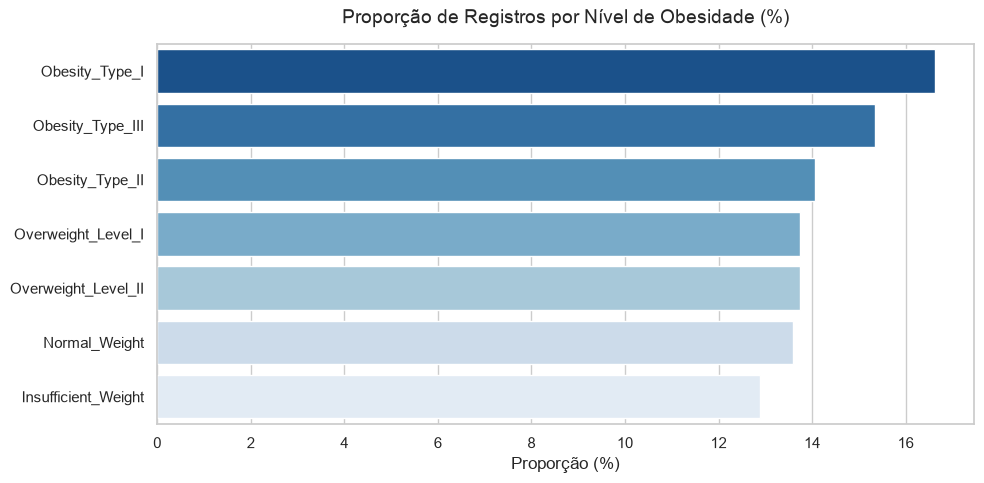

In [23]:
distribuicao_alvo = pd.DataFrame({
    'Contagem': df['NObeyesdad'].value_counts(),
    'Proporção (%)': (df['NObeyesdad'].value_counts(normalize=True) * 100).round(2)
})

display(Markdown("**Distribuição da Variável Alvo (NObeyesdad):**"))
display(distribuicao_alvo)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=distribuicao_alvo['Proporção (%)'], 
    y=distribuicao_alvo.index, 
    palette='Blues_r',
    hue=distribuicao_alvo.index,
    legend=False
)
plt.title('Proporção de Registros por Nível de Obesidade (%)', fontsize=14, pad=15)
plt.xlabel('Proporção (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [24]:
display(Markdown("**Estatísticas - Variáveis Numéricas:**"))
display(df.describe().round(2))

display(Markdown("**Estatísticas - Variáveis Categóricas:**"))
display(df.describe(include=['object', 'str']))

**Estatísticas - Variáveis Numéricas:**

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


**Estatísticas - Variáveis Categóricas:**

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


## Pré-Processamento

#### Renomeação de Colunas

In [25]:
rename_columns = {
    'FAVC': 'high_calorie_food',
    'FCVC': 'vegetables_frequency',
    'NCP': 'number_meals',
    'CAEC': 'eat_between_meals',
    'CH2O': 'water',
    'SCC': 'monitor_calories',
    'FAF': 'physical_activities_frequency',
    'TUE': 'screen_time',
    'CALC': 'alcohol',
    'MTRANS': 'means_transportation',
    'NObeyesdad': 'obesity'
}
df.rename(columns=rename_columns, inplace=True)

#### Arredondamento de Dados Sintéticos

In [26]:
colunas_arredondar = ['vegetables_frequency', 'number_meals', 'water', 'physical_activities_frequency', 'screen_time']
df[colunas_arredondar] = df[colunas_arredondar].round()

#### Ordinal Encoding

In [27]:
mapa_frequencia = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df['eat_between_meals'] = df['eat_between_meals'].map(mapa_frequencia)
df['alcohol'] = df['alcohol'].map(mapa_frequencia)

#### One-Hot Encoding

In [28]:
colunas_nominais = ['Gender', 'family_history_with_overweight', 'high_calorie_food', 'SMOKE', 'monitor_calories', 'means_transportation']
df = pd.get_dummies(df, columns=colunas_nominais, drop_first=True, dtype=int)

#### Target Encoding

In [29]:
X = df.drop('obesity', axis=1)
y_raw = df['obesity']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

#### Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Standardization (Escalonamento)

In [31]:
colunas_escalonar = ['Age', 'Height', 'Weight'] + colunas_arredondar

scaler = StandardScaler()
X_train[colunas_escalonar] = scaler.fit_transform(X_train[colunas_escalonar])
X_test[colunas_escalonar] = scaler.transform(X_test[colunas_escalonar])

display(Markdown("**Dimensões dos dados após o pré-processamento:**"))
display(pd.DataFrame({
    'Conjunto': ['Treino (X_train)', 'Teste (X_test)'],
    'Linhas': [X_train.shape[0], X_test.shape[0]],
    'Colunas/Features': [X_train.shape[1], X_test.shape[1]]
}))

**Dimensões dos dados após o pré-processamento:**

,Conjunto,Linhas,Colunas/Features
0,Treino (X_train),1688,19
1,Teste (X_test),423,19


## Execução e Avaliação do Naive Bayes

#### Para este modelo, foi utilizada a implementação do GaussianNB

In [32]:
    nb_model = GaussianNB()
    nb_model.fit(X_train, y_train)
    
    y_pred_nb = nb_model.predict(X_test)

**Métricas Consolidadas:**

,Métrica,Resultado
0,Acurácia,0.5319
1,Precisão,0.5907
2,Recall,0.5276
3,F1-Score,0.4601


**Desempenho Detalhado por Nível de Obesidade:**

,precision,recall,f1-score
Insufficient_Weight,0.4397,0.9444,0.6000
Normal_Weight,0.4667,0.1207,0.1918
Obesity_Type_I,0.5574,0.4857,0.5191
Obesity_Type_II,0.3916,0.9333,0.5517
Obesity_Type_III,0.9846,0.9846,0.9846
Overweight_Level_I,0.4375,0.1207,0.1892
Overweight_Level_II,0.8571,0.1034,0.1846


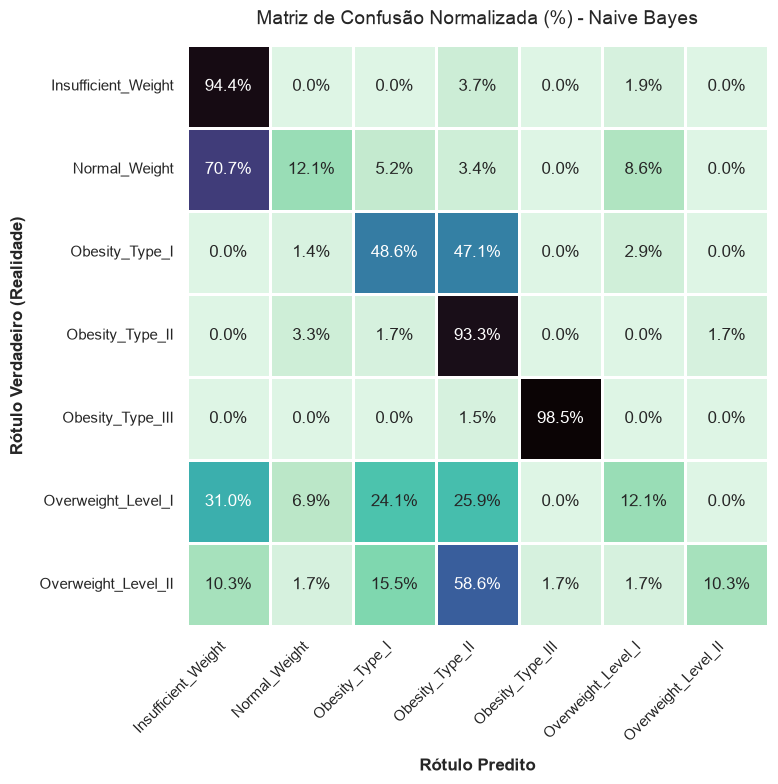

In [33]:
report = classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_, output_dict=True)

df_consolidado = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Resultado': [
        report['accuracy'], 
        report['macro avg']['precision'], 
        report['macro avg']['recall'], 
        report['macro avg']['f1-score']
    ]
})
df_consolidado['Resultado'] = df_consolidado['Resultado'].apply(lambda x: f"{x:.4f}")

display(Markdown("**Métricas Consolidadas:**"))
display(df_consolidado)

df_classes = pd.DataFrame(report).transpose()
df_classes = df_classes.drop(['accuracy', 'macro avg', 'weighted avg'])
df_classes = df_classes.drop(columns=['support'])

display(Markdown("**Desempenho Detalhado por Nível de Obesidade:**"))
display(df_classes.round(4))

cm_norm = confusion_matrix(y_test, y_pred_nb, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt=".1%", 
    cmap="mako_r", 
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar=False, 
    square=True, 
    linewidths=1, 
    linecolor='white',
    ax=ax
)

plt.title('Matriz de Confusão Normalizada (%) - Naive Bayes', fontsize=14, pad=15)
plt.xlabel('Rótulo Predito', fontsize=12, labelpad=10, fontweight='bold')
plt.ylabel('Rótulo Verdadeiro (Realidade)', fontsize=12, labelpad=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- **Desempenho baixo já esperado.**
- **O bias indutivo no Naive Bayes é a suposição de independência entre as features.**
- **Em um dataset em que as features são fortemente dependentes, o Naive Bayes possui desempenho ruim.**
- **O pré-processamento também não gera efeitos positivos nesse tipo de algoritmo**

---
## Construção da Arquitetura do Multilayer Perceptron

- **Framework Pytorch**
- **Duas camadas ocultas (64 e 32 neurônios)**
- **ReLU como função de ativação**
- **Dropout de 20% após 1° camada oculta para evitar overfitting**
- **CrossEntropyLoss como função de perda e otimizador**

#### Imports

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import ipywidgets as widgets
from torch.utils.data import DataLoader, TensorDataset

#### Conversão dos Dados para Tensores

In [35]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

#### DataLoaders para Operar em mini-batches

In [36]:
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#### Arquitetura e função de treinamento reutilizável

In [37]:
class ObesityMLP(nn.Module):
    def __init__(self, input_size, num_classes=7):
        super(ObesityMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def treinar_e_avaliar_mlp(learning_rate, epochs=50):
    input_size = X_train_tensor.shape[1]
    model = ObesityMLP(input_size)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        train_losses.append(epoch_loss / len(train_loader))
        
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            y_pred_list.extend(predicted.numpy())
            
    return model, train_losses, np.array(y_pred_list)

## Treinamento e Avaliação de 3 Variações do MLP
**Exploração de diferentes valores de Learning Rate**

In [38]:
estilo = {'description_width': 'initial'}
opcoes_lr = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0001]

lr1_drop = widgets.Dropdown(options=opcoes_lr, value=0.1, description='Variação 1 (LR):', style=estilo)
lr2_drop = widgets.Dropdown(options=opcoes_lr, value=0.01, description='Variação 2 (LR):', style=estilo)
lr3_drop = widgets.Dropdown(options=opcoes_lr, value=0.0001, description='Variação 3 (LR):', style=estilo)

botao_treinar = widgets.Button(description='Treinar e Comparar', button_style='success', icon='play')
saida_graficos = widgets.Output()

def ao_clicar_treinar(b):
    with saida_graficos:
        clear_output(wait=True)
        print("Treinando as 3 variações da Rede Neural...")
        
        taxas = [lr1_drop.value, lr2_drop.value, lr3_drop.value]
        historico_loss = []
        resultados_f1 = []
        modelos_treinados = []
        
        for i, lr in enumerate(taxas):
            print(f"Treinando Variação {i+1} (LR: {lr})...")
            modelo, losses, preds = treinar_e_avaliar_mlp(learning_rate=lr, epochs=60)
            
            historico_loss.append(losses)
            modelos_treinados.append(modelo)
            resultados_f1.append(f1_score(y_test, preds, average='macro'))
            
        print("Treinamento concluído! Gerando gráficos de comparação...")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        cores = ['#e63946', '#2a9d8f', '#e9c46a']
        
        for i in range(3):
            ax1.plot(historico_loss[i], label=f'MLP (LR: {taxas[i]})', color=cores[i], linewidth=2)
        
        ax1.set_title('Convergência: Evolução do Erro (Loss) por Época', fontsize=13, pad=15)
        ax1.set_xlabel('Época')
        ax1.set_ylabel('Cross Entropy Loss')
        ax1.legend()
        
        f1_nb_val = report['macro avg']['f1-score'] 
        
        nomes_modelos = ['Naive Bayes\n(Baseline)'] + [f'MLP\n(LR: {lr})' for lr in taxas]
        valores_barras = [f1_nb_val] + resultados_f1
        cores_barras = ['#8d99ae'] + cores
        
        bars = ax2.bar(nomes_modelos, valores_barras, color=cores_barras)
        ax2.set_title('Performance Final: F1-Score (Macro)', fontsize=13, pad=15)
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel('F1-Score')
        
        for bar in bars:
            altura = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., altura + 0.01, f'{altura:.4f}', ha='center', va='bottom', fontweight='bold')
            
        plt.tight_layout()
        plt.show()

botao_treinar.on_click(ao_clicar_treinar)
display(widgets.HBox([lr1_drop, lr2_drop, lr3_drop]))
display(botao_treinar, saida_graficos)

Button(button_style='success', description='Treinar e Comparar', icon='play', style=ButtonStyle())

Output()

---

## Dataset 2

### Predição de Evasão Escolar e Sucesso Acadêmico
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

### Modelos Aplicados
- Regressão Logística
- Random Forest

---

#### Imports

In [14]:
from IPython.display import display, Markdown, Image, clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets

## EDA

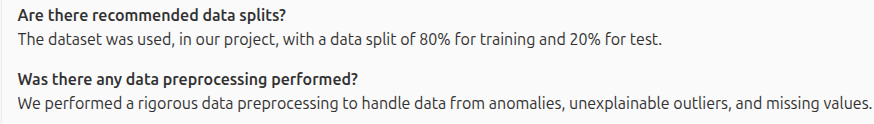

In [4]:
Image(filename='assets/dataset_info2.png', width=1500)

In [5]:
sns.set_theme(style="whitegrid")

df_dropout = pd.read_csv('students.csv', sep=';') 

display(Markdown("**Amostra Inicial dos Dados:**"))
display(df_dropout.head())

resumo_estrutural = pd.DataFrame({
    'Tipo de Dado': df_dropout.dtypes,
    'Valores Nulos': df_dropout.isna().sum(),
    'Valores Únicos': df_dropout.nunique()
})

display(Markdown("**Resumo Estrutural das Variáveis:**"))
display(resumo_estrutural)

**Amostra Inicial dos Dados:**

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Resumo Estrutural das Variáveis:**

,Tipo de Dado,Valores Nulos,Valores Únicos
Marital status,int64,0,6
Application mode,int64,0,18
Application order,int64,0,8
Course,int64,0,17
Daytime/evening attendance\t,int64,0,2
Previous qualification,int64,0,17
Previous qualification (grade),float64,0,101
Nacionality,int64,0,21
Mother's qualification,int64,0,29
Father's qualification,int64,0,34


**Distribuição da Variável Alvo (Target):**

,Contagem,Proporção (%)
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


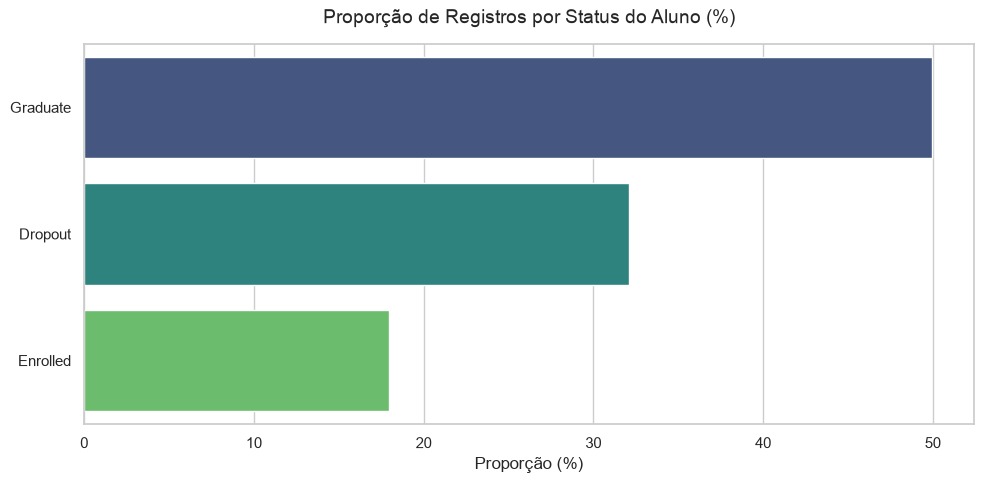

In [6]:
distribuicao_alvo = pd.DataFrame({
    'Contagem': df_dropout['Target'].value_counts(),
    'Proporção (%)': (df_dropout['Target'].value_counts(normalize=True) * 100).round(2)
})

display(Markdown("**Distribuição da Variável Alvo (Target):**"))
display(distribuicao_alvo)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=distribuicao_alvo['Proporção (%)'], 
    y=distribuicao_alvo.index, 
    palette='viridis',
    hue=distribuicao_alvo.index,
    legend=False
)
plt.title('Proporção de Registros por Status do Aluno (%)', fontsize=14, pad=15)
plt.xlabel('Proporção (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Pré Processamento

#### One-Hot Encoding

In [7]:
colunas_categoricas_disfarcadas = [
    'Marital status', 'Application mode', 'Course', 
    'Previous qualification', 'Nacionality', 
    "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation"
]

df_dropout = pd.get_dummies(df_dropout, columns=colunas_categoricas_disfarcadas, drop_first=True, dtype=int)

#### Remoção da Classe Enrolled e Target Encoding

In [8]:
df_dropout = df_dropout[df_dropout['Target'] != 'Enrolled']

X = df_dropout.drop('Target', axis=1)
y_raw = df_dropout['Target']

label_encoder_dropout = LabelEncoder()
y = label_encoder_dropout.fit_transform(y_raw)

#### Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Standardization

In [10]:
scaler_dropout = StandardScaler()
X_train_scaled = scaler_dropout.fit_transform(X_train)
X_test_scaled = scaler_dropout.transform(X_test)

display(Markdown("**Dimensões dos dados após o pré-processamento:**"))
display(pd.DataFrame({
    'Conjunto': ['Treino (X_train_scaled)', 'Teste (X_test_scaled)'],
    'Linhas': [X_train_scaled.shape[0], X_test_scaled.shape[0]],
    'Colunas/Features': [X_train_scaled.shape[1], X_test_scaled.shape[1]]
}))

**Dimensões dos dados após o pré-processamento:**

,Conjunto,Linhas,Colunas/Features
0,Treino (X_train_scaled),2904,238
1,Teste (X_test_scaled),726,238


## Execução e Avaliação do Modelo de Regressão Logística

**Tabela 1 - Métricas Consolidadas (Visão Geral do Modelo):**

,Métrica,Resultado
0,Acurácia,0.9008
1,Precisão (Macro),0.9016
2,Recall (Macro),0.8890
3,F1-Score (Macro),0.8943


**Tabela 2 - Desempenho Detalhado por Status do Aluno:**

,precision,recall,f1-score
Dropout,0.9046,0.8345,0.8681
Graduate,0.8987,0.9434,0.9205


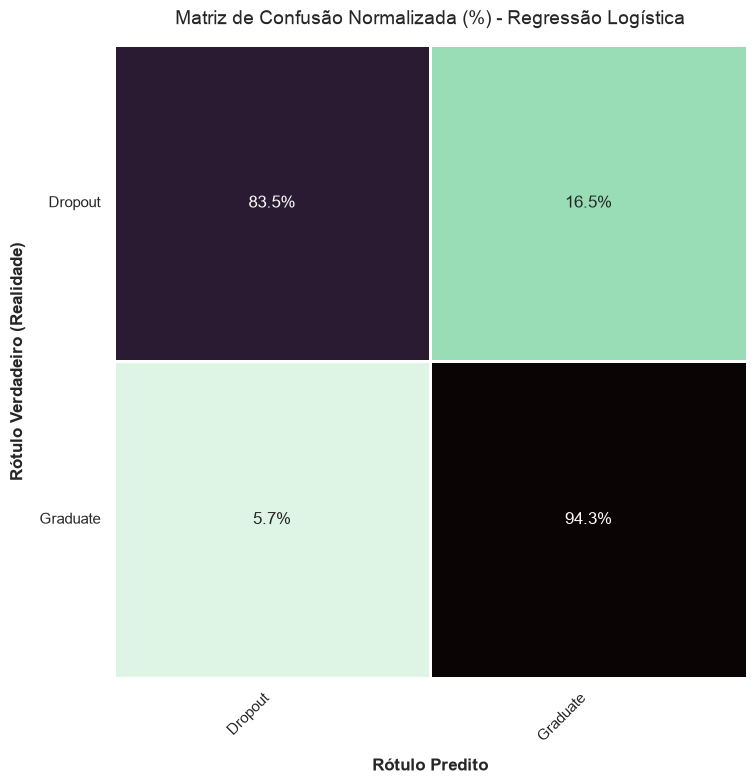

In [11]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

report_lr = classification_report(y_test, y_pred_lr, target_names=label_encoder_dropout.classes_, output_dict=True)

df_consolidado_lr = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Resultado': [
        report_lr['accuracy'], 
        report_lr['macro avg']['precision'], 
        report_lr['macro avg']['recall'], 
        report_lr['macro avg']['f1-score']
    ]
})
df_consolidado_lr['Resultado'] = df_consolidado_lr['Resultado'].apply(lambda x: f"{x:.4f}")

display(Markdown("**Tabela 1 - Métricas Consolidadas (Visão Geral do Modelo):**"))
display(df_consolidado_lr)

df_classes_lr = pd.DataFrame(report_lr).transpose()
df_classes_lr = df_classes_lr.drop(['accuracy', 'macro avg', 'weighted avg']).drop(columns=['support'])

display(Markdown("**Tabela 2 - Desempenho Detalhado por Status do Aluno:**"))
display(df_classes_lr.round(4))

cm_norm_lr = confusion_matrix(y_test, y_pred_lr, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm_lr, annot=True, fmt=".1%", cmap="mako_r", 
    xticklabels=label_encoder_dropout.classes_, yticklabels=label_encoder_dropout.classes_,
    cbar=False, square=True, linewidths=1, linecolor='white', ax=ax
)

plt.title('Matriz de Confusão Normalizada (%) - Regressão Logística', fontsize=14, pad=15)
plt.xlabel('Rótulo Predito', fontsize=12, labelpad=10, fontweight='bold')
plt.ylabel('Rótulo Verdadeiro (Realidade)', fontsize=12, labelpad=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- **A remoção da classe 'Enrolled' permitiu avaliarmos de maneira clara alunos que evadem e que se formam**
- **Modelo teve bom desempenho, mostrando que alunos formados e evadidos possuem perfis diferentes**

#### Análise de Impacto das Variáveis (Odds Ratio)

In [12]:
pd.set_option('display.max_colwidth', None)

dicionario_humanizado = {
    'Age at enrollment': 'O aumento da idade do aluno no momento da matrícula',
    'Unemployment rate': 'A alta na taxa de desemprego na região',
    'Inflation rate': 'A alta na taxa de inflação',
    'GDP': 'O aumento do PIB (Produto Interno Bruto)',
    'Curricular units 1st sem (credited)': 'Ter mais disciplinas validadas/creditadas no 1º semestre',
    'Curricular units 1st sem (enrolled)': 'Matricular-se em mais disciplinas no 1º semestre',
    'Curricular units 1st sem (evaluations)': 'Realizar mais avaliações (provas/trabalhos) no 1º semestre',
    'Curricular units 1st sem (approved)': 'O aumento no número de disciplinas aprovadas no 1º semestre',
    'Curricular units 1st sem (grade)': 'A elevação da média de notas no 1º semestre',
    'Curricular units 1st sem (without evaluations)': 'Deixar mais disciplinas sem avaliação no 1º semestre',
    'Curricular units 2nd sem (credited)': 'Ter mais disciplinas validadas/creditadas no 2º semestre',
    'Curricular units 2nd sem (enrolled)': 'Matricular-se em mais disciplinas no 2º semestre',
    'Curricular units 2nd sem (evaluations)': 'Realizar mais avaliações (provas/trabalhos) no 2º semestre',
    'Curricular units 2nd sem (approved)': 'O aumento no número de disciplinas aprovadas no 2º semestre',
    'Curricular units 2nd sem (grade)': 'A elevação da média de notas no 2º semestre',
    'Curricular units 2nd sem (without evaluations)': 'Deixar mais disciplinas sem avaliação no 2º semestre',
    'Admission grade': 'Possuir uma nota maior no exame de admissão',
    'Previous qualification (grade)': 'Possuir uma nota maior na formação escolar anterior',
    'Displaced': 'Mudar de cidade natal para estudar (Estudante deslocado)',
    'Educational special needs': 'Possuir necessidades educacionais especiais',
    'Debtor': 'Possuir dívidas ativas com a instituição (Inadimplência)',
    'Tuition fees up to date': 'Estar com o pagamento das mensalidades rigorosamente em dia',
    'Gender': 'Ser do gênero masculino',
    'Scholarship holder': 'Ser contemplado com uma bolsa de estudos',
    'International': 'Ser um estudante internacional',
    'Daytime/evening attendance': 'Estudar no turno diurno'
}

dict_cursos = {
    '33': 'Tecnologias de Produção de Biocombustíveis', '171': 'Design de Animação e Multimídia', 
    '8014': 'Serviço Social (Noturno)', '9003': 'Agronomia', '9070': 'Design de Comunicação', 
    '9085': 'Enfermagem Veterinária', '9119': 'Engenharia Informática', '9130': 'Equinocultura', 
    '9147': 'Gestão', '9238': 'Serviço Social', '9254': 'Turismo', '9500': 'Enfermagem', 
    '9556': 'Higiene Oral', '9670': 'Gestão de Publicidade e Marketing', 
    '9773': 'Jornalismo e Comunicação', '9853': 'Educação Básica', '9991': 'Gestão (Noturno)'
}

dict_estado_civil = {
    '1': 'Solteiro(a)', '2': 'Casado(a)', '3': 'Viúvo(a)', '4': 'Divorciado(a)', 
    '5': 'União Estável', '6': 'Separado(a) Legalmente'
}

def criar_frase_explicativa(coluna_original, variacao_perc):
    verbo = "reduz" if variacao_perc < 0 else "aumenta"
    impacto_formatado = f"{abs(variacao_perc):.1f}%"
    
    sujeito = coluna_original
    
    if coluna_original in dicionario_humanizado:
        sujeito = f"• {dicionario_humanizado[coluna_original]}"
    elif '_' in coluna_original:
        prefixo, codigo = coluna_original.split('_', 1)
        if prefixo == 'Course':
            sujeito = f"• Estar matriculado no curso de {dict_cursos.get(codigo, f'(Cód. {codigo})')}"
        elif prefixo == 'Marital status':
            sujeito = f"• Ter o estado civil: {dict_estado_civil.get(codigo, f'(Cód. {codigo})')}"
        elif prefixo == 'Application mode':
            sujeito = f"• Ingressar por meio de modalidade específica (Cód. {codigo})"
        elif prefixo == 'Nacionality':
            sujeito = f"• Possuir nacionalidade estrangeira (Cód. {codigo})"
        elif prefixo == "Mother's occupation":
            sujeito = f"• Ter a mãe trabalhando na profissão (Cód. {codigo})"
        elif prefixo == "Father's occupation":
            sujeito = f"• Ter o pai trabalhando na profissão (Cód. {codigo})"
        elif prefixo == "Mother's qualification" or prefixo == "Father's qualification":
            sujeito = f"• Nível de escolaridade dos pais (Cód. {codigo})"
        else:
            sujeito = f"• A característica {prefixo} ({codigo})"

    return f"{sujeito} {verbo} o risco de evasão em {impacto_formatado}."

coeficientes_dropout = -lr_model.coef_[0]

df_impacto = pd.DataFrame({
    'Indicador Original': X.columns,
    'Coeficiente': coeficientes_dropout,
    'Odds_Ratio': np.exp(coeficientes_dropout)
})

df_impacto['Variacao_Percentual'] = (df_impacto['Odds_Ratio'] - 1) * 100

df_impacto['Análise'] = df_impacto.apply(
    lambda row: criar_frase_explicativa(row['Indicador Original'], row['Variacao_Percentual']), axis=1
)

risco_top = df_impacto.sort_values(by='Coeficiente', ascending=False).head(5)
protecao_top = df_impacto.sort_values(by='Coeficiente', ascending=True).head(5)

estilo_tabela = {'text-align': 'left', 'font-size': '14px', 'padding': '8px'}

display(Markdown("### O que mais impacta a Evasão"))
display(Markdown("*Nota técnica: Os percentuais refletem a alteração de risco a cada 1 desvio padrão nas métricas.*"))
display(risco_top[['Análise']].style.hide(axis='index').set_properties(**estilo_tabela))

display(Markdown("<br>"))

display(Markdown("### Fatores Protetores contra a Evasão"))
display(protecao_top[['Análise']].style.hide(axis='index').set_properties(**estilo_tabela))

### O que mais impacta a Evasão

*Nota técnica: Os percentuais refletem a alteração de risco a cada 1 desvio padrão nas métricas.*

Análise
• Matricular-se em mais disciplinas no 2º semestre aumenta o risco de evasão em 407.4%.
• Matricular-se em mais disciplinas no 1º semestre aumenta o risco de evasão em 112.7%.
• Possuir dívidas ativas com a instituição (Inadimplência) aumenta o risco de evasão em 67.5%.
• Estar matriculado no curso de Educação Básica aumenta o risco de evasão em 50.8%.
• Ter o pai trabalhando na profissão (Cód. 9) aumenta o risco de evasão em 48.7%.


<br>

### Fatores Protetores contra a Evasão

Análise
• O aumento no número de disciplinas aprovadas no 2º semestre reduz o risco de evasão em 96.1%.
• O aumento no número de disciplinas aprovadas no 1º semestre reduz o risco de evasão em 85.7%.
• Estar com o pagamento das mensalidades rigorosamente em dia reduz o risco de evasão em 61.8%.
• A elevação da média de notas no 2º semestre reduz o risco de evasão em 43.7%.
• Estar matriculado no curso de Serviço Social reduz o risco de evasão em 27.3%.


---
## Construção,  Treinamento e Avaliação do Modelo de Random Forest
- **Balanceamento de classe minoritária (class_weight)**
- **Poda via min_sample_leaf**
- **Variação do hiperparâmetro `max_depth`**

In [18]:
estilo = {'description_width': 'initial'}
opcoes_depth = [2, 5, 10, 15, 20, 30, 50, 100]

depth1_drop = widgets.Dropdown(options=opcoes_depth, value=2, description='Variação 1 (max_depth):', style=estilo)
depth2_drop = widgets.Dropdown(options=opcoes_depth, value=15, description='Variação 2 (max_depth):', style=estilo)
depth3_drop = widgets.Dropdown(options=opcoes_depth, value=100, description='Variação 3 (max_depth):', style=estilo)

botao_treinar_rf = widgets.Button(description='Treinar Florestas', button_style='success', icon='tree')
saida_rf = widgets.Output()

def ao_clicar_treinar_rf(b):
    with saida_rf:
        clear_output(wait=True)
        print("Plantando as 3 Random Forests...")
        
        profundidades = [depth1_drop.value, depth2_drop.value, depth3_drop.value]
        
        f1_treino = []
        f1_teste = []
        acc_teste = []
        prec_teste = []
        rec_teste = []
        
        for depth in profundidades:
            d = None if depth == 100 else depth
            
            rf_model = RandomForestClassifier(
                n_estimators=100, 
                max_depth=d, 
                class_weight='balanced',
                min_samples_leaf=2,
                random_state=42, 
                n_jobs=-1
)
            rf_model.fit(X_train_scaled, y_train)
            
            y_pred_train = rf_model.predict(X_train_scaled)
            f1_treino.append(f1_score(y_train, y_pred_train, average='macro'))
            
            y_pred_test = rf_model.predict(X_test_scaled)
            f1_teste.append(f1_score(y_test, y_pred_test, average='macro'))
            acc_teste.append(accuracy_score(y_test, y_pred_test))
            prec_teste.append(precision_score(y_test, y_pred_test, average='macro', zero_division=0))
            rec_teste.append(recall_score(y_test, y_pred_test, average='macro'))

        
        fig, ax = plt.subplots(figsize=(10, 6.5))
        
        largura_barra = 0.35
        indices = np.arange(len(profundidades))
        
        bars_train = ax.bar(indices - largura_barra/2, f1_treino, largura_barra, label='Performance no Treino', color='#1d3557', edgecolor='white', linewidth=1)
        bars_test = ax.bar(indices + largura_barra/2, f1_teste, largura_barra, label='Performance no Teste', color='#457b9d', edgecolor='white', linewidth=1)
        
        nomes_eixo = [f'Profundidade: {d}' if d != 100 else 'Profundidade: Ilimitada\n(Risco de Overfitting)' for d in profundidades]
        ax.set_xticks(indices)
        ax.set_xticklabels(nomes_eixo, fontsize=11)
        
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('F1-Score (Macro)', fontweight='bold', labelpad=10)
        ax.set_title('Diagnóstico: Overfitting, Underfitting e Generalização', fontsize=14, pad=20, fontweight='bold')
        
        ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)
        
        for bar in bars_train + bars_test:
            altura = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., altura + 0.01, f'{altura:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')
            
        ax.axhline(y=float(df_consolidado_lr['Resultado'].iloc[3]), color='#e63946', linestyle='--', linewidth=2, label='Baseline (Reg. Logística)')
        
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=11)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.2) 
        plt.show()

        df_metricas_rf = pd.DataFrame({
            'Variação (max_depth)': [str(d) if d != 100 else 'Ilimitada (100)' for d in profundidades],
            'Acurácia': acc_teste,
            'Precisão (Macro)': prec_teste,
            'Recall (Macro)': rec_teste,
            'F1-Score (Macro)': f1_teste
        })
        
        for col in ['Acurácia', 'Precisão (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']:
            df_metricas_rf[col] = df_metricas_rf[col].apply(lambda x: f"{x:.4f}")
            
        display(Markdown("<br> Resumo das Métricas (Conjunto de Teste)"))
        display(df_metricas_rf.style.hide(axis='index').set_properties(**{'text-align': 'center'}))

botao_treinar_rf.on_click(ao_clicar_treinar_rf)
display(widgets.HBox([depth1_drop, depth2_drop, depth3_drop]))
display(botao_treinar_rf, saida_rf)

Button(button_style='success', description='Treinar Florestas', icon='tree', style=ButtonStyle())

Output()

- **Com a remoção dos 'Enrolled' a classificação fica tão simples que até uma árvore de profundidade 2 consegue um F1-Score acima de 0.85**
- **Leve uderfitting na árvore de profundidade 2. Se os dados fossem mais complexos, veríamos claramente um overfitting na árvore de profundidade 100**
- **Penalização de erros na classe minoritária (class_weight) contornou o desbalanceamento natural dos dados, e a poda auxiliou com a alta dimensionalidade do One-Hot Ecoding (238 features)**